Sequential baseline for 1k.txt: 53587.0 µs
Threads=2, Time=94536.0 µs
Threads=4, Time=56980.0 µs
Threads=6, Time=58114.0 µs
Threads=8, Time=50447.0 µs
Threads=10, Time=42096.0 µs
Threads=12, Time=40732.0 µs
Threads=14, Time=39053.0 µs
Threads=16, Time=37396.0 µs
Threads=18, Time=41490.0 µs
Threads=20, Time=37664.0 µs
Threads=22, Time=38643.0 µs
Threads=24, Time=40691.0 µs
Threads=26, Time=43353.0 µs
Threads=28, Time=43152.0 µs
Threads=30, Time=37235.0 µs
Threads=32, Time=40419.0 µs


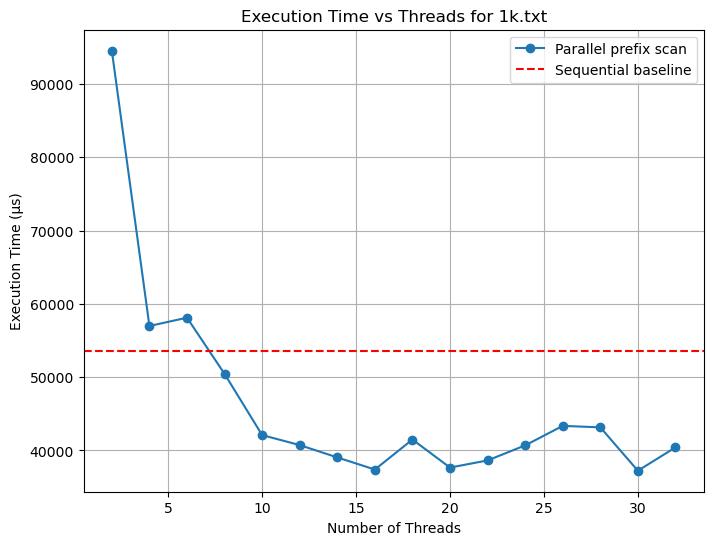

Sequential baseline for 8k.txt: 438110.0 µs
Threads=2, Time=702612.0 µs
Threads=4, Time=433208.0 µs
Threads=6, Time=330816.0 µs
Threads=8, Time=305078.0 µs
Threads=10, Time=263665.0 µs
Threads=12, Time=247949.0 µs
Threads=14, Time=232998.0 µs
Threads=16, Time=216403.0 µs
Threads=18, Time=207898.0 µs
Threads=20, Time=186794.0 µs
Threads=22, Time=199349.0 µs
Threads=24, Time=195641.0 µs
Threads=26, Time=196974.0 µs
Threads=28, Time=217520.0 µs
Threads=30, Time=192162.0 µs
Threads=32, Time=186862.0 µs


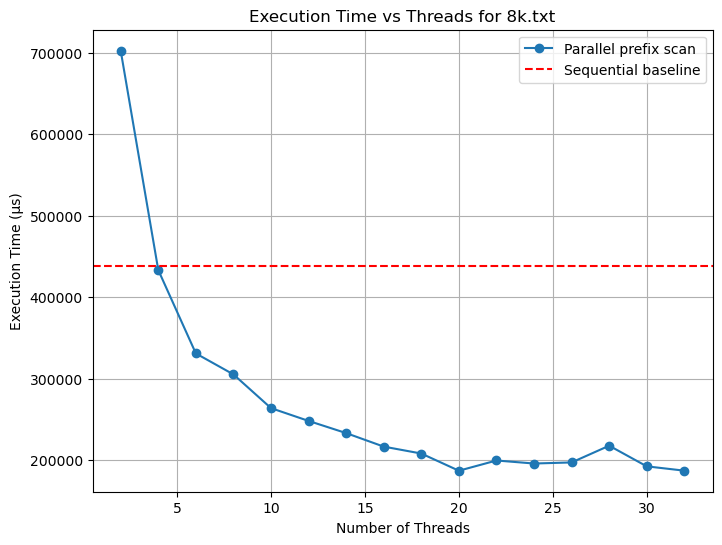

Sequential baseline for 16k.txt: 962652.0 µs
Threads=2, Time=1443461.0 µs
Threads=4, Time=778741.0 µs
Threads=6, Time=600287.0 µs
Threads=8, Time=524856.0 µs
Threads=10, Time=473914.0 µs
Threads=12, Time=430732.0 µs
Threads=14, Time=424068.0 µs
Threads=16, Time=405234.0 µs
Threads=18, Time=418898.0 µs
Threads=20, Time=401898.0 µs
Threads=22, Time=412299.0 µs
Threads=24, Time=412128.0 µs
Threads=26, Time=395469.0 µs
Threads=28, Time=372563.0 µs
Threads=30, Time=346646.0 µs
Threads=32, Time=375491.0 µs


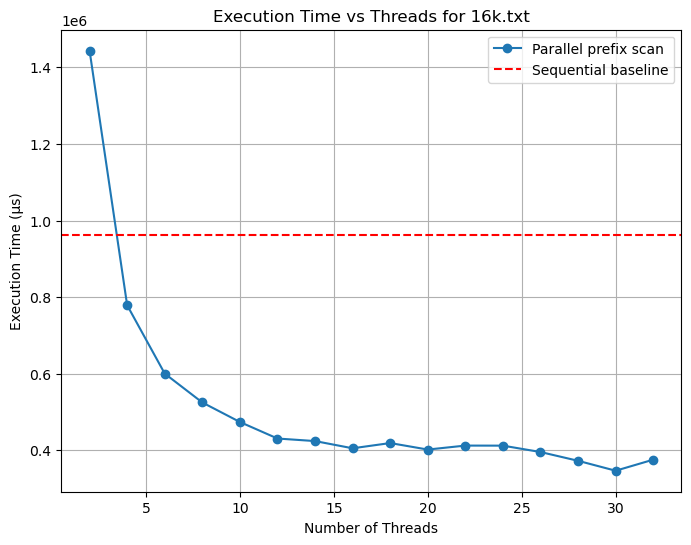

Sequential baseline for seq_64_test.txt: 3402.0 µs
Threads=2, Time=7461.0 µs
Threads=4, Time=6496.0 µs
Threads=6, Time=5669.0 µs
Threads=8, Time=6026.0 µs
Threads=10, Time=7038.0 µs
Threads=12, Time=7514.0 µs
Threads=14, Time=7511.0 µs
Threads=16, Time=8102.0 µs
Threads=18, Time=7490.0 µs
Threads=20, Time=9051.0 µs
Threads=22, Time=9382.0 µs
Threads=24, Time=8942.0 µs
Threads=26, Time=9804.0 µs
Threads=28, Time=9380.0 µs
Threads=30, Time=10245.0 µs
Threads=32, Time=10480.0 µs


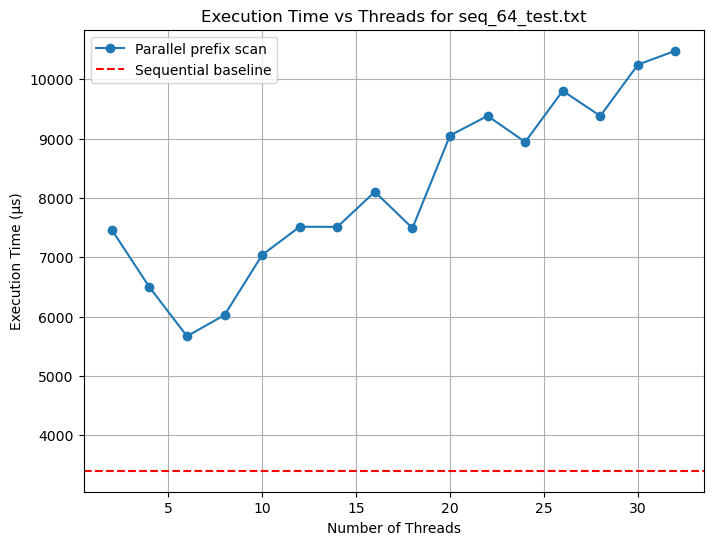

In [ ]:
#!/usr/bin/env python3
import re
import subprocess
import matplotlib.pyplot as plt

# Binaries for each version of k-means
binaries = {
    "CPU": "./bin/kmeans_cpu",
    "CUDA_basic": "./bin/kmeans_cuda_basic",
    "CUDA_shmem": "./bin/kmeans_cuda_shmem",
    "Thrust": "./bin/kmeans_thrust"
}

# Input files to test (filename, dims)
inputs = [
    ("random-n2048-d16-c16.txt", 16),
    ("random-n16384-d24-c16.txt", 24),
    ("random-n65536-d32-c16.txt", 32)
]

# Common params
k = 16
max_iter = 150
threshold = 1e-5
seed = 8675309

results = {}  # (impl, input) -> (iters, ms_per_iter)

for impl, binpath in binaries.items():
    for fname, dims in inputs:
        cmd = f"{binpath} -k {k} -d {dims} -i inputs/{fname} -m {max_iter} -t {threshold} -s {seed}"
        print("Running:", cmd)
        try:
            out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT).decode()
        except subprocess.CalledProcessError as e:
            print(f"[ERROR] {impl} on {fname} failed:\n{e.output.decode()}")
            continue

        # Output should have a line like: "150,0.123456"
        m = re.search(r"(\d+)\s*,\s*([0-9]*\.?[0-9]+)", out)
        if not m:
            print(f"[WARN] No timing found for {impl} / {fname}")
            print("Output was:\n", out)
            continue

        iters = int(m.group(1))
        ms_per_iter = float(m.group(2))
        results[(impl, fname)] = (iters, ms_per_iter)

        print(f" -> {impl} {fname}: {iters} iters, {ms_per_iter:.6f} ms/iter")

# Plot simple bar charts per input file
for fname, dims in inputs:
    plt.figure(figsize=(8, 4))
    labels, times = [], []
    for impl in binaries.keys():
        key = (impl, fname)
        if key in results:
            labels.append(impl)
            times.append(results[key][1])

    plt.bar(labels, times)
    plt.title(f"{fname} (dims={dims})")
    plt.ylabel("ms / iteration")
    plt.tight_layout()
    plt.show()
